In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from matplotlib.colors import ListedColormap

iris = load_iris()

In [3]:
#load dataset and prepare binary classification
iris=load_iris()
X=iris.data[:,:2]
y=iris.target

#filter out class 2(virgincia) for bin class
X=X[y !=2]
y=y[y !=2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
clf_lr=LogisticRegression()
clf_lr.fit(X_train, y_train)
y_pred_lr=clf_lr.predict(X_test)

print(" logistic regression:\n")
print(classification_report(y_test, y_pred_lr))

 logistic regression:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
clf_nb=GaussianNB()
clf_nb.fit(X_train, y_train)
y_pred_nb=clf_nb.predict(X_test)

print(" naive bayes:\n")
print(classification_report(y_test, y_pred_nb))

 naive bayes:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



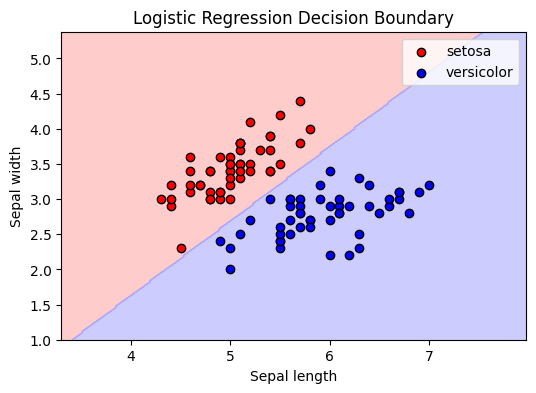

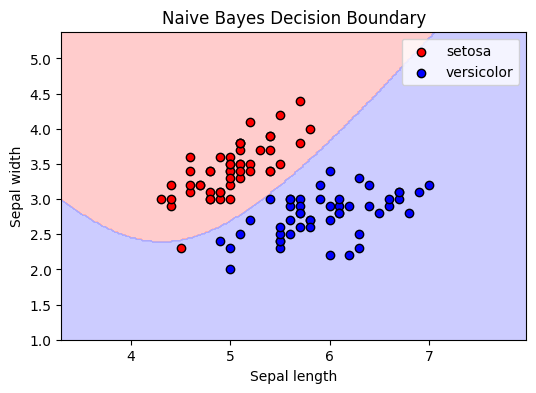

In [8]:
def plot_decision_boundary(model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ['red', 'blue']

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    for i, color in zip(np.unique(y), cmap_bold):
        plt.scatter(X[y == i, 0], X[y == i, 1], c=color, label=iris.target_names[i], edgecolor='k')

    plt.title(title)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.legend()
    plt.show()

plot_decision_boundary(clf_lr, "Logistic Regression Decision Boundary")
plot_decision_boundary(clf_nb, "Naive Bayes Decision Boundary")


gaussian nb from scratch


In [10]:
import numpy as np

# Training data
# X -> [x1, x2]
X = np.array([
    [1.0, 2.0],
    [1.2, 1.9],
    [3.0, 3.1],
    [3.2, 2.9]
])

# Labels
y = np.array([0, 0, 1, 1])


In [11]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0) + 1e-9  # avoid divide by zero
            self.prior[c] = X_c.shape[0] / X.shape[0]

    def gaussian_pdf(self, x, mean, var):
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = []

            for c in self.classes:
                prior = np.log(self.prior[c])
                likelihood = np.sum(
                    np.log(self.gaussian_pdf(x, self.mean[c], self.var[c]))
                )
                posterior = prior + likelihood
                posteriors.append(posterior)

            predictions.append(self.classes[np.argmax(posteriors)])

        return np.array(predictions)


In [12]:
model = GaussianNaiveBayes()
model.fit(X, y)

# Test point
X_test = np.array([[2.0, 2.1]])

prediction = model.predict(X_test)
print("Predicted class:", prediction[0])


Predicted class: 0


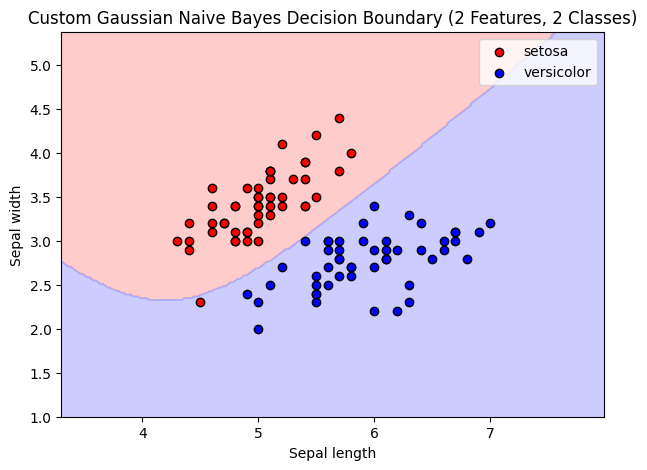

In [18]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

data = load_iris()
# Select only the first two features (sepal length and sepal width) for 2D plotting
X_full = data.data[:, :2]
y_full = data.target

# Filter out class 2 (virginica) for binary classification
X = X_full[y_full != 2]
y = y_full[y_full != 2]

# The GaussianNaiveBayes class is already defined in cell yYJ7DYv_7e6r and is in scope.

# Redefine the plot_decision_boundary function within this cell, adapted for 2 classes
def plot_decision_boundary(model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict on the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Define colormaps for 2 classes
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ['red', 'blue']

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    # Plot training points for each class
    # Adjust target_names to reflect only the two classes being plotted
    target_names_2_classes = [data.target_names[i] for i in np.unique(y)]
    for i, color in zip(np.unique(y), cmap_bold):
        plt.scatter(X[y == i, 0], X[y == i, 1], c=color, label=target_names_2_classes[i], edgecolor='k')

    plt.title(title)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.legend()
    plt.show()

# Instantiate and train the custom Gaussian Naive Bayes model using the 2-feature X and 2-class y
model_custom_gnb = GaussianNaiveBayes()
model_custom_gnb.fit(X, y)

# Plot the decision boundary for the custom model
plot_decision_boundary(model_custom_gnb, "Custom Gaussian Naive Bayes Decision Boundary (2 Features, 2 Classes)")

In [14]:
class GaussianNaiveBayes:
    def __init__(self):
        self.classes = None
        self.mean = {}
        self.var = {}
        self.prior = {}

    def fit(self, X, y):
        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0) + 1e-9  # numerical stability
            self.prior[c] = X_c.shape[0] / X.shape[0]

    def gaussian_pdf(self, x, mean, var):
        return np.exp(-(x - mean) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

    def predict(self, X):
        if self.classes is None:
            raise RuntimeError("Call fit() before predict().")

        predictions = []

        for x in X:
            posteriors = []

            for c in self.classes:
                log_prior = np.log(self.prior[c])
                log_likelihood = np.sum(
                    np.log(self.gaussian_pdf(x, self.mean[c], self.var[c]))
                )
                posteriors.append(log_prior + log_likelihood)

            predictions.append(self.classes[np.argmax(posteriors)])

        return np.array(predictions)


In [15]:
# Simple train-test split (manual)
X_train, X_test = X[:120], X[120:]
y_train, y_test = y[:120], y[120:]

model = GaussianNaiveBayes()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [16]:
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)


Accuracy: 0.9333333333333333


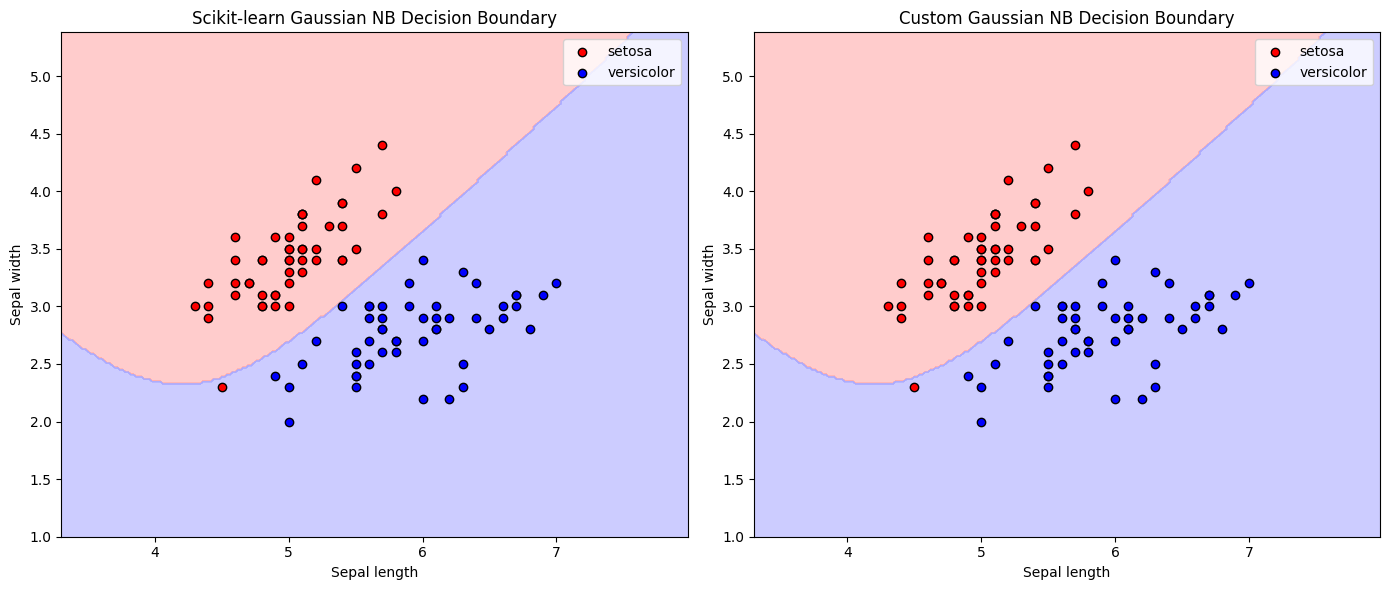

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from matplotlib.colors import ListedColormap

# Re-load iris and filter for 2 classes for consistent comparison
iris = load_iris()
X_compare = iris.data[:, :2] # Use only the first two features for plotting
y_compare = iris.target

X_compare = X_compare[y_compare != 2] # Filter out class 2 (virginica)
y_compare = y_compare[y_compare != 2]

# Get target names for the two classes
target_names_2_classes = [iris.target_names[i] for i in np.unique(y_compare)]

# Instantiate and train scikit-learn Gaussian Naive Bayes
clf_nb_sk = GaussianNB()
clf_nb_sk.fit(X_compare, y_compare)

# Instantiate and train custom Gaussian Naive Bayes (assuming the class is defined in another cell)
model_custom_gnb = GaussianNaiveBayes()
model_custom_gnb.fit(X_compare, y_compare)

# Define a plot function for decision boundaries adapted for comparison
def plot_decision_boundary_comparison(model, X_data, y_data, title, target_names):
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ['red', 'blue']

    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    for i, color in zip(np.unique(y_data), cmap_bold):
        plt.scatter(X_data[y_data == i, 0], X_data[y_data == i, 1], c=color, label=target_names[i], edgecolor='k')

    plt.title(title)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.legend()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_decision_boundary_comparison(clf_nb_sk, X_compare, y_compare, "Scikit-learn Gaussian NB Decision Boundary", target_names_2_classes)

plt.subplot(1, 2, 2)
plot_decision_boundary_comparison(model_custom_gnb, X_compare, y_compare, "Custom Gaussian NB Decision Boundary", target_names_2_classes)

plt.tight_layout()
plt.show()

Test Accuracy: 0.5558
Theta shape: (10, 784)
Variance shape: (10, 784)


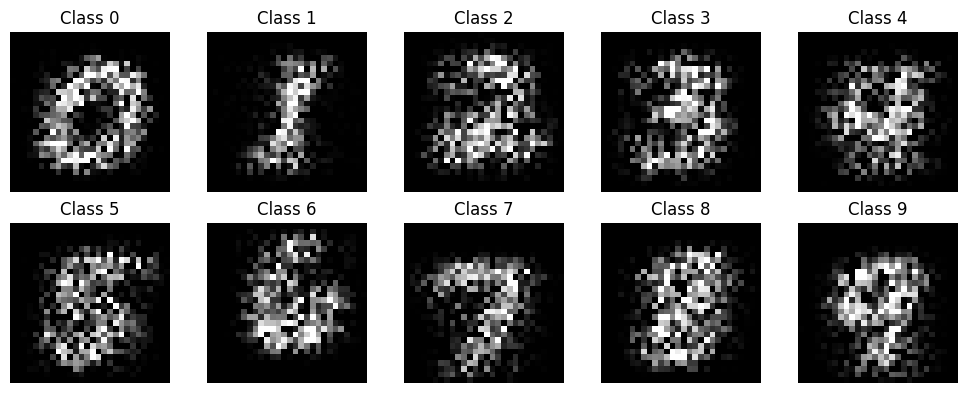

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


# 1. Load MNIST data from TensorFlow

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0


# 2. Flatten 28x28 images to 784-dimensional vectors

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 3. Train Gaussian Naive Bayes (10-class classifier)

gnb = GaussianNB()
gnb.fit(X_train_flat, y_train)

# Optional: evaluate classifier
y_pred = gnb.predict(X_test_flat)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# 4. Access learned distributions

# gnb.theta_ -> mean of each pixel per class
# gnb.var_   -> variance of each pixel per class
print("Theta shape:", gnb.theta_.shape)  # (10, 784)
print("Variance shape:", gnb.var_.shape) # (10, 784)

# 5. Generate new data using learned Gaussians
def generate_digit(class_label, model):
    mean = model.theta_[class_label]
    var = model.var_[class_label]

    # Sample each pixel independently
    sample = np.random.normal(mean, np.sqrt(var))

    # Clip to valid range
    sample = np.clip(sample, 0, 1)

    return sample.reshape(28, 28)

# 6. Visualize generated digits

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in enumerate(axes.flat):
    generated_image = generate_digit(digit, gnb)
    ax.imshow(generated_image, cmap="gray")
    ax.set_title(f"Class {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

